In [12]:
import pandas as pd

# 1. Carga del archivo
df = pd.read_csv('22-26_historico.csv')

# Convertir fecha para poder detectar el día de la semana
df['Fecha_dt'] = pd.to_datetime(df['Fecha'], format='%d/%m/%Y', errors='coerce')

# Función de limpieza de importes para las comparaciones numéricas
def clean_num(val):
    if pd.isna(val): return 0.0
    val_str = str(val).replace('"', '').replace('.', '').replace(',', '.')
    try: return float(val_str)
    except: return 0.0

# --- PROCESO DE CORRECCIÓN ---

# A. Identificar Ingresos de "Papá" (Domingos + 50€)
# Si es Ingreso, es Domingo (dayofweek == 6) e Importe es 50
def corregir_ingresos(row):
    importe_num = clean_num(row['Importe'])
    if row['Tipo'] == 'Ingreso' and row['Fecha_dt'].dayofweek == 6 and importe_num == 50.0:
        row['Descripción'] = 'Papá'
        row['Compromiso'] = 'Fijo'
    return row

# B. Identificar Combustible (Categoría Coche + importes específicos)
importes_combustible = [20.0, 25.0, 30.0, 35.0, 40.0, 45.0, 50.0]

def corregir_combustible(row):
    importe_num = clean_num(row['Importe'])
    # Si la categoría es Coche o Moto y el importe cuadra con los habituales de gasolinera
    if row['Categoría'] in ['Coche', 'Moto'] and importe_num in importes_combustible:
        row['Descripción'] = 'Diésel'
        row['Compromiso'] = 'Fijo'
    return row

# Aplicar las correcciones
df = df.apply(corregir_ingresos, axis=1)
df = df.apply(corregir_combustible, axis=1)

# Eliminar la columna auxiliar de fecha y guardar
df_final = df.drop(columns=['Fecha_dt'])

# Guardar el nuevo CSV limpio
df_final.to_csv('22-26_historico_corregido.csv', index=False, encoding='utf-8-sig')

print("✅ CSV Actualizado:")
print(f"- Ingresos de los domingos de 50€ marcados como 'Papá' y 'Fijo'.")
print(f"- Gastos de Coche/Moto de {importes_combustible}€ marcados como 'Diésel' y 'Fijo'.")

✅ CSV Actualizado:
- Ingresos de los domingos de 50€ marcados como 'Papá' y 'Fijo'.
- Gastos de Coche/Moto de [20.0, 25.0, 30.0, 35.0, 40.0, 45.0, 50.0]€ marcados como 'Diésel' y 'Fijo'.


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar el dataset
df = pd.read_csv('22-26_historico_corregido.csv')

# Función robusta para limpiar el importe
def limpiar_importe(valor):
    if pd.isna(valor): return 0.0
    val_str = str(valor).strip()
    # Si hay coma, es formato europeo (1.234,56). 
    # Quitamos los puntos de miles y cambiamos la coma por punto decimal.
    if ',' in val_str:
        val_str = val_str.replace('.', '').replace(',', '.')
    return float(val_str)

# Aplicar la limpieza y convertir fechas
df['Importe'] = df['Importe'].apply(limpiar_importe)
df['Fecha'] = pd.to_datetime(df['Fecha'], format='%d/%m/%Y')

# Añadir columnas temporales para el análisis
df['Año'] = df['Fecha'].dt.year
df['Mes'] = df['Fecha'].dt.month
df['Mes_Año'] = df['Fecha'].dt.to_period('M')

print("✅ Datos cargados y limpios.")

✅ Datos cargados y limpios.


In [14]:
# 1. Balance por año (Ingresos vs Gastos)
balance_anual = df.pivot_table(index='Año', columns='Tipo', values='Importe', aggfunc='sum', fill_value=0)
balance_anual['Diferencia (Ahorro)'] = balance_anual['Ingreso'] - balance_anual['Gasto']
print("\n--- BALANCE POR AÑO ---")
print(balance_anual)

# 2. Ranking de Gastos por Categoría (Histórico)
top_categorias = df[df['Tipo'] == 'Gasto'].groupby('Categoría')['Importe'].sum().sort_values(ascending=False)
print("\n--- DONDE SE VA EL DINERO (Top Categorías) ---")
print(top_categorias.head(10))

# 3. El "Índice Café" (Basado en tu lógica anterior)
cafes = df[df['Descripción'] == 'Café']
print(f"\n--- ESTADÍSTICA DE CAFÉ ---")
print(f"Total gastado en café: {cafes['Importe'].sum():.2f} €")
print(f"Número total de cafés: {len(cafes)}")


--- BALANCE POR AÑO ---
Tipo    Gasto  Ingreso  Inversión  Diferencia (Ahorro)
Año                                                   
2022  4531.93  7131.04       0.00              2599.11
2023  9156.24  9622.82       0.00               466.58
2024  7730.12  9681.49       0.00              1951.37
2025  7359.05  8811.50       0.00              1452.45
2026   766.41  3451.24     456.97              2684.83

--- DONDE SE VA EL DINERO (Top Categorías) ---
Categoría
Ocio          9461.53
Coche         5010.86
Tecnología    4239.79
Moto          3416.16
Recambios     2579.07
Ropa          2484.83
Salud         1076.95
Otro           551.30
Billetazo      300.00
Transporte     295.31
Name: Importe, dtype: float64

--- ESTADÍSTICA DE CAFÉ ---
Total gastado en café: 323.94 €
Número total de cafés: 223


## 1. Evolución Temporal (¿Gasto más ahora que en 2022?)

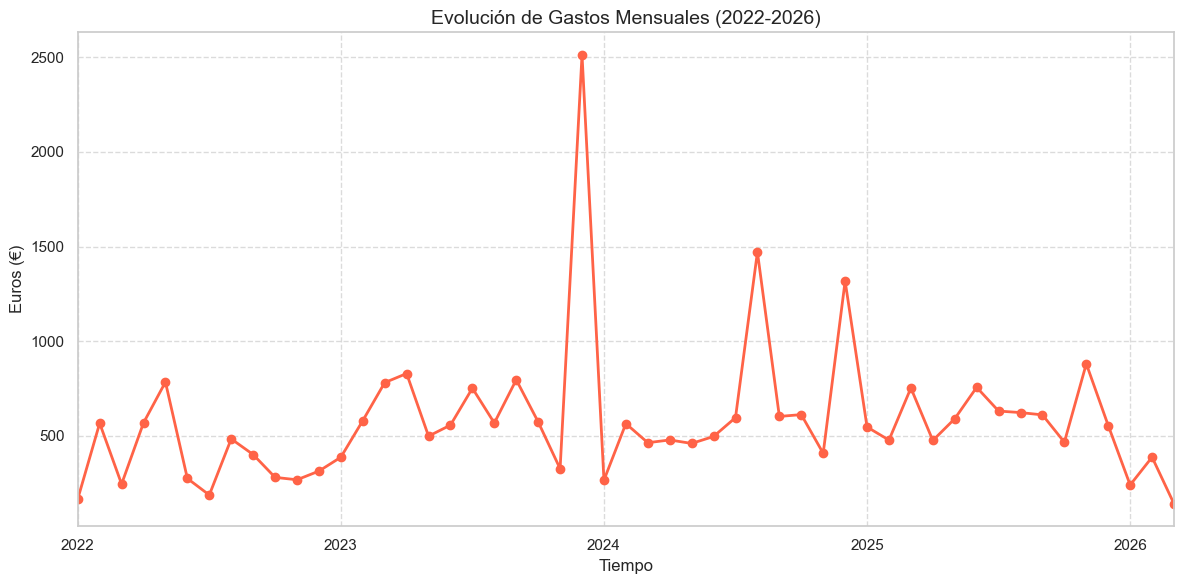

In [15]:
# Gráfico de evolución mensual de gastos
plt.figure(figsize=(12, 6))
gastos_mensuales = df[df['Tipo'] == 'Gasto'].groupby('Mes_Año')['Importe'].sum()
gastos_mensuales.plot(kind='line', marker='o', color='tomato', linewidth=2)

plt.title('Evolución de Gastos Mensuales (2022-2026)', fontsize=14)
plt.ylabel('Euros (€)')
plt.xlabel('Tiempo')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 2. Distribución por Categoría (¿En qué se me va el dinero?)

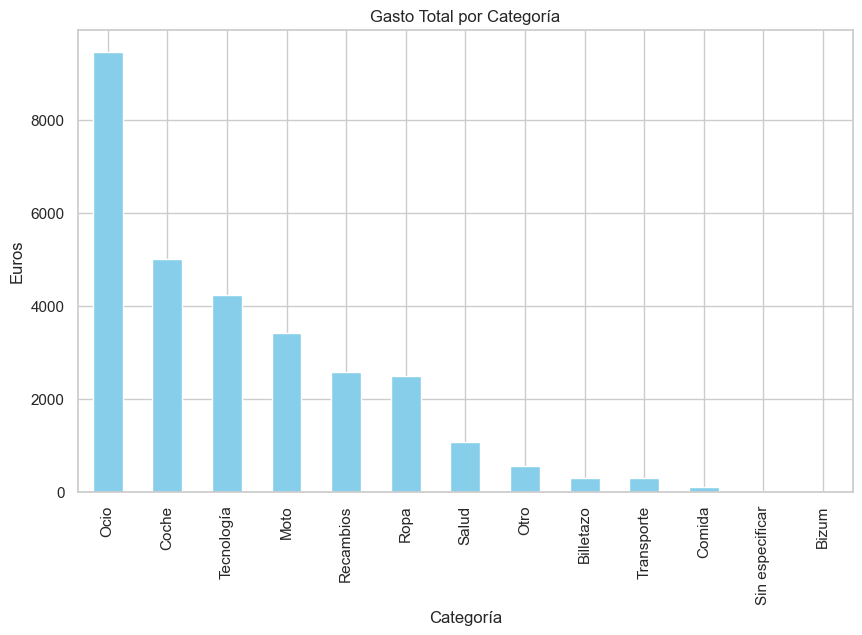

In [16]:
top_gastos = df[df['Tipo'] == 'Gasto'].groupby('Categoría')['Importe'].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
top_gastos.plot(kind='bar', color='skyblue')
plt.title('Gasto Total por Categoría')
plt.ylabel('Euros')
plt.show()

## 3. Mapa de calor (¿Qué meses son los más críticos?)


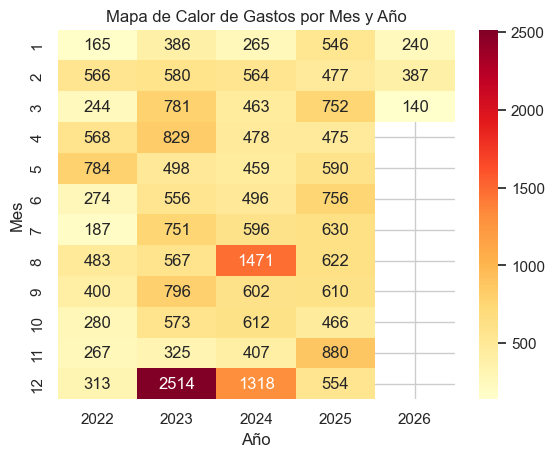

In [18]:

pivot_df = df[df['Tipo'] == 'Gasto'].pivot_table(index='Mes', columns='Año', values='Importe', aggfunc='sum')
sns.heatmap(pivot_df, annot=True, fmt=".0f", cmap="YlOrRd")
plt.title('Mapa de Calor de Gastos por Mes y Año')
plt.show()

# Modelo

📊 INFORME FINANCIERO (2022-2026) 📊

1. BALANCE TOTAL POR TIPO:
   - Ingreso: 38,698.09 €
   - Gasto: 29,543.75 €
   - Inversión: 456.97 €

   💰 Liquidez Restante (Ahorro): 8,697.37 €
   📈 Tasa de Ahorro/Inversión: 23.7% de tus ingresos

2. TOP 5 CATEGORÍAS DE GASTO:
   - Ocio: 9,461.53 € (32.0%)
   - Coche: 5,010.86 € (17.0%)
   - Tecnología: 4,239.79 € (14.4%)
   - Moto: 3,416.16 € (11.6%)
   - Recambios: 2,579.07 € (8.7%)

3. COMPROMISO DEL GASTO (Fijo vs Variable):
   - Fijo: 2,545.12 € (8.6%)
   - Variable: 26,998.63 € (91.4%)

4. DISTRIBUCIÓN DE INVERSIONES:
   - Fondo Inversión: 280.00 €
   - Crypto: 116.97 €
   - ETF: 60.00 €


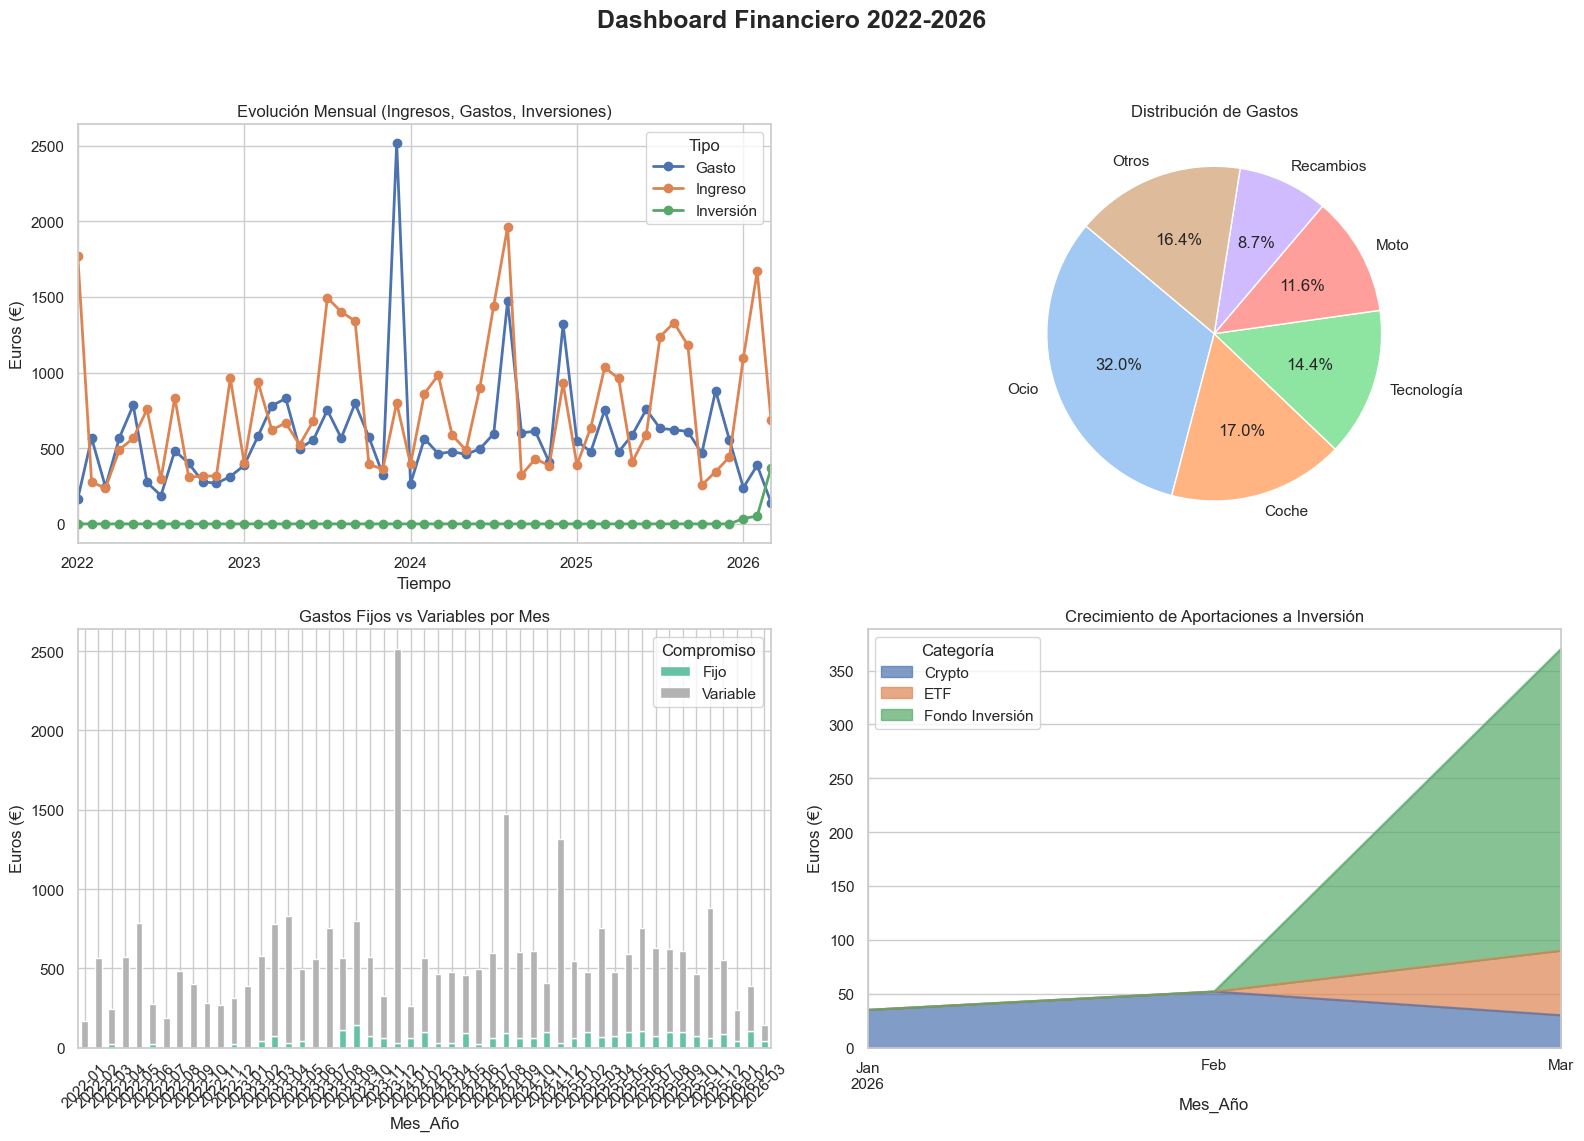

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. CARGA Y LIMPIEZA DE DATOS
def limpiar_importe(valor):
    if pd.isna(valor): return 0.0
    val_str = str(valor).replace(' €', '').strip()
    if ',' in val_str:
        val_str = val_str.replace('.', '').replace(',', '.')
    try:
        return float(val_str)
    except:
        return 0.0

# Asegúrate de poner el nombre correcto de tu archivo CSV
df = pd.read_csv('22-26_historico_corregido.csv')

# Limpiar columnas clave
df['Importe'] = df['Importe'].apply(limpiar_importe)
df['Fecha'] = pd.to_datetime(df['Fecha'], format='%d/%m/%Y', errors='coerce')

# Eliminar filas donde la fecha no se pudo leer
df = df.dropna(subset=['Fecha'])

# Crear columnas de tiempo para el análisis
df['Año'] = df['Fecha'].dt.year
df['Mes'] = df['Fecha'].dt.month
df['Mes_Año'] = df['Fecha'].dt.to_period('M')

# Configuración visual de los gráficos
sns.set_theme(style="whitegrid")

# ==========================================
# REPORTE FINANCIERO COMPLETO
# ==========================================

print("📊 INFORME FINANCIERO (2022-2026) 📊")
print("="*40)

# --- BLOQUE 1: RESUMEN GENERAL ---
resumen_tipo = df.groupby('Tipo')['Importe'].sum().sort_values(ascending=False)
print("\n1. BALANCE TOTAL POR TIPO:")
for tipo, total in resumen_tipo.items():
    print(f"   - {tipo}: {total:,.2f} €")

ingresos_totales = resumen_tipo.get('Ingreso', 0)
gastos_totales = resumen_tipo.get('Gasto', 0)
inversiones_totales = resumen_tipo.get('Inversión', 0)

ahorro_neto = ingresos_totales - gastos_totales - inversiones_totales
tasa_ahorro_inversion = ((inversiones_totales + ahorro_neto) / ingresos_totales) * 100 if ingresos_totales > 0 else 0

print(f"\n   💰 Liquidez Restante (Ahorro): {ahorro_neto:,.2f} €")
print(f"   📈 Tasa de Ahorro/Inversión: {tasa_ahorro_inversion:.1f}% de tus ingresos")

# --- BLOQUE 2: RADIOGRAFÍA DE GASTOS ---
df_gastos = df[df['Tipo'] == 'Gasto']

print("\n2. TOP 5 CATEGORÍAS DE GASTO:")
top_gastos = df_gastos.groupby('Categoría')['Importe'].sum().sort_values(ascending=False).head(5)
for cat, total in top_gastos.items():
    porcentaje = (total / gastos_totales) * 100
    print(f"   - {cat}: {total:,.2f} € ({porcentaje:.1f}%)")

print("\n3. COMPROMISO DEL GASTO (Fijo vs Variable):")
gastos_compromiso = df_gastos.groupby('Compromiso')['Importe'].sum()
for comp, total in gastos_compromiso.items():
    porcentaje = (total / gastos_totales) * 100
    print(f"   - {comp}: {total:,.2f} € ({porcentaje:.1f}%)")

# --- BLOQUE 3: ANÁLISIS DE INVERSIONES ---
df_inv = df[df['Tipo'] == 'Inversión']
if not df_inv.empty:
    print("\n4. DISTRIBUCIÓN DE INVERSIONES:")
    inv_cat = df_inv.groupby('Categoría')['Importe'].sum().sort_values(ascending=False)
    for cat, total in inv_cat.items():
        print(f"   - {cat}: {total:,.2f} €")


# ==========================================
# GRÁFICOS DE TENDENCIAS
# ==========================================

fig, axs = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Dashboard Financiero 2022-2026', fontsize=18, fontweight='bold')

# Gráfico 1: Evolución temporal de Ingresos vs Gastos vs Inversiones
tendencia_mensual = df.pivot_table(index='Mes_Año', columns='Tipo', values='Importe', aggfunc='sum', fill_value=0)
tendencia_mensual.plot(ax=axs[0, 0], marker='o', linewidth=2)
axs[0, 0].set_title('Evolución Mensual (Ingresos, Gastos, Inversiones)')
axs[0, 0].set_ylabel('Euros (€)')
axs[0, 0].set_xlabel('Tiempo')

# Gráfico 2: Distribución de Gastos (Pie chart de top categorías + Otros)
gastos_pie = df_gastos.groupby('Categoría')['Importe'].sum().sort_values(ascending=False)
if len(gastos_pie) > 5:
    otros = gastos_pie[5:].sum()
    gastos_pie = gastos_pie[:5]
    gastos_pie['Otros'] = otros
axs[0, 1].pie(gastos_pie, labels=gastos_pie.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("pastel"))
axs[0, 1].set_title('Distribución de Gastos')

# Gráfico 3: Gastos Fijos vs Variables a lo largo del tiempo
tendencia_compromiso = df_gastos.pivot_table(index='Mes_Año', columns='Compromiso', values='Importe', aggfunc='sum', fill_value=0)
tendencia_compromiso.plot(kind='bar', stacked=True, ax=axs[1, 0], colormap='Set2')
axs[1, 0].set_title('Gastos Fijos vs Variables por Mes')
axs[1, 0].set_ylabel('Euros (€)')
axs[1, 0].tick_params(axis='x', rotation=45)

# Gráfico 4: Evolución de Inversiones por Categoría
if not df_inv.empty:
    tendencia_inv = df_inv.pivot_table(index='Mes_Año', columns='Categoría', values='Importe', aggfunc='sum', fill_value=0)
    tendencia_inv.plot(kind='area', stacked=True, ax=axs[1, 1], alpha=0.7)
    axs[1, 1].set_title('Crecimiento de Aportaciones a Inversión')
    axs[1, 1].set_ylabel('Euros (€)')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

10:43:02 - cmdstanpy - INFO - Chain [1] start processing


🧠 Entrenando modelo predictivo para buscar patrones ocultos...



10:43:02 - cmdstanpy - INFO - Chain [1] done processing


🕵️‍♂️ RESULTADOS DEL DETECTIVE FINANCIERO:

📅 DÍA PELIGROSO: Estadísticamente, gastas más dinero los Sábados de forma recurrente.
🛡️ DÍA SEGURO: Tu día de mayor contención y ahorro son los Martess.

⚠️ ALERTA MENSUAL: Agosto es históricamente tu mes de mayor fuga de capital.
🌱 OPORTUNIDAD: Noviembre es tu mes natural de menor gasto (ideal para invertir más).

📈 INFLACIÓN INVISIBLE (Categorías que se están encareciendo):
   🚨 Ocio: El coste medio de cada pago ha subido un 98.2% recientemente.


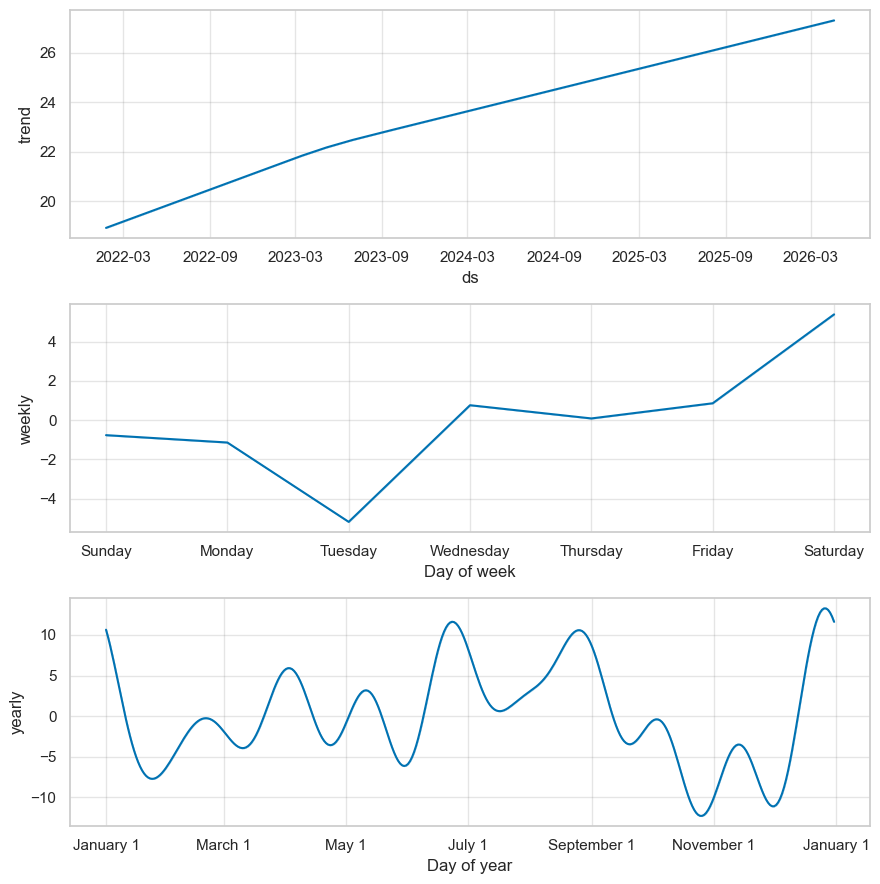

In [20]:
import pandas as pd
import numpy as np
from prophet import Prophet
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore') # Ocultar avisos molestos de Prophet

# 1. CARGA Y LIMPIEZA ADAPTADA A TU FORMATO
def limpiar_importe(valor):
    if pd.isna(valor): return 0.0
    val_str = str(valor).replace(' €', '').replace('"', '').strip()
    if ',' in val_str:
        val_str = val_str.replace('.', '').replace(',', '.')
    try:
        return float(val_str)
    except:
        return 0.0

df = pd.read_csv('22-26_historico.csv')
df['Importe'] = df['Importe'].apply(limpiar_importe)
df['Fecha'] = pd.to_datetime(df['Fecha'], format='%d/%m/%Y', errors='coerce')
df = df.dropna(subset=['Fecha'])

# 2. PREPARACIÓN DE DATOS (Filtrando anomalías extremas)
df_gastos = df[df['Tipo'] == 'Gasto'].groupby('Fecha')['Importe'].sum().reset_index()
df_gastos.columns = ['ds', 'y']

# Calculamos el percentil 95 para "suavizar" gastos gigantes (ej: una moto de 4000€)
limite_anomalia = df_gastos['y'].quantile(0.95)
df_gastos['y_limpia'] = np.where(df_gastos['y'] > limite_anomalia, limite_anomalia, df_gastos['y'])

df_prophet = df_gastos[['ds', 'y_limpia']].rename(columns={'y_limpia': 'y'})

# 3. ENTRENAMIENTO DEL MODELO DE IA
print("🧠 Entrenando modelo predictivo para buscar patrones ocultos...\n")
m = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
m.fit(df_prophet)

future = m.make_future_dataframe(periods=30)
forecast = m.predict(future)

# ==========================================
# EXTRACCIÓN AUTOMÁTICA DE PATRONES OCULTOS
# ==========================================
print("🕵️‍♂️ RESULTADOS DEL DETECTIVE FINANCIERO:\n")

# --- PATRÓN SEMANAL ---
dias_semana = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']
weekly_seasonality = forecast.groupby(forecast['ds'].dt.dayofweek)['weekly'].mean()
dia_max = dias_semana[weekly_seasonality.idxmax()]
dia_min = dias_semana[weekly_seasonality.idxmin()]

print(f"📅 DÍA PELIGROSO: Estadísticamente, gastas más dinero los {dia_max}s de forma recurrente.")
print(f"🛡️ DÍA SEGURO: Tu día de mayor contención y ahorro son los {dia_min}s.")

# --- PATRÓN ANUAL ---
meses = ['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio', 'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre']
monthly_seasonality = forecast.groupby(forecast['ds'].dt.month)['yearly'].mean()
mes_max = monthly_seasonality.idxmax()
mes_min = monthly_seasonality.idxmin()

print(f"\n⚠️ ALERTA MENSUAL: {meses[mes_max-1]} es históricamente tu mes de mayor fuga de capital.")
print(f"🌱 OPORTUNIDAD: {meses[mes_min-1]} es tu mes natural de menor gasto (ideal para invertir más).")

# --- TENDENCIAS INVISIBLES DE CATEGORÍAS ---
print("\n📈 INFLACIÓN INVISIBLE (Categorías que se están encareciendo):")
df_gastos_cat = df[df['Tipo'] == 'Gasto'].copy()
hace_6_meses = df_gastos_cat['Fecha'].max() - pd.DateOffset(months=6)

# Comparamos el gasto medio por ticket de los últimos 6 meses vs el resto del histórico
gastos_recientes = df_gastos_cat[df_gastos_cat['Fecha'] >= hace_6_meses].groupby('Categoría')['Importe'].mean()
gastos_antiguos = df_gastos_cat[df_gastos_cat['Fecha'] < hace_6_meses].groupby('Categoría')['Importe'].mean()

patrones_encontrados = False
for cat in gastos_recientes.index:
    if cat in gastos_antiguos.index and gastos_antiguos[cat] > 5: # Filtro para evitar divisiones por cero o montos ínfimos
        crecimiento = ((gastos_recientes[cat] - gastos_antiguos[cat]) / gastos_antiguos[cat]) * 100
        # Si el ticket medio ha subido más de un 20%
        if crecimiento > 20:
            print(f"   🚨 {cat}: El coste medio de cada pago ha subido un {crecimiento:.1f}% recientemente.")
            patrones_encontrados = True

if not patrones_encontrados:
    print("   ✅ No se detectan subidas alarmantes en el ticket medio de tus categorías habituales.")

# 4. GRÁFICOS DE APOYO
fig = m.plot_components(forecast)
plt.show()

🔍 DESGLOSE DEL GASTO EN OCIO:
                   ticket_medio  gasto_maximo  veces_al_mes
Periodo                                                    
Histórico Antiguo      9.633047         165.0     18.458050
Últimos 6 meses       19.061529         360.0     14.166667

🏪 COMPARATIVA POR DESCRIPCIÓN (Sitios habituales):
Periodo          Histórico Antiguo  Últimos 6 meses  Variación %
Descripción                                                     
Comida                    8.849259        16.700000    88.716360
Entretenimiento          18.227236        24.826667    36.206424


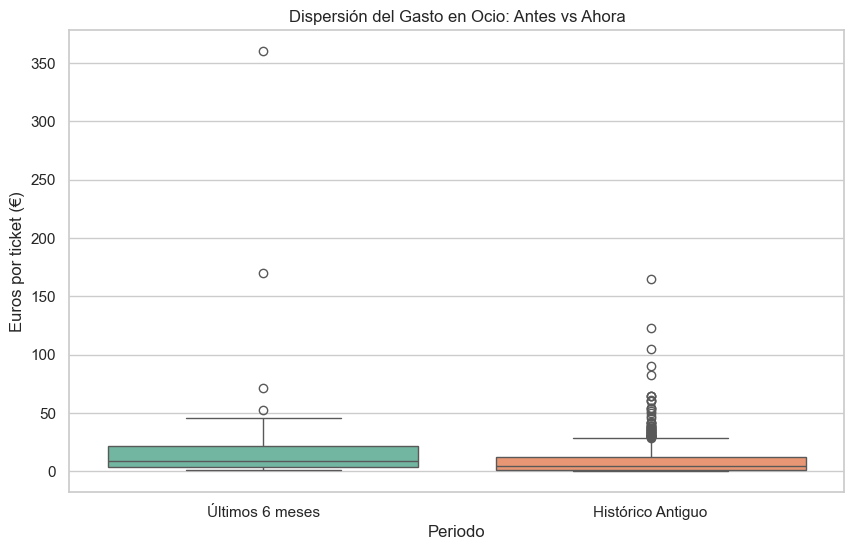

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Preparar datos de Ocio
df_ocio = df[df['Categoría'] == 'Ocio'].copy()
hace_6_meses = df_ocio['Fecha'].max() - pd.DateOffset(months=6)

# Crear dos grupos: Reciente vs Histórico
df_ocio['Periodo'] = np.where(df_ocio['Fecha'] >= hace_6_meses, 'Últimos 6 meses', 'Histórico Antiguo')

# 2. Análisis de métricas
stats_ocio = df_ocio.groupby('Periodo').agg(
    ticket_medio=('Importe', 'mean'),
    gasto_maximo=('Importe', 'max'),
    veces_al_mes=('Fecha', lambda x: len(x) / ((x.max() - x.min()).days / 30) if (x.max() - x.min()).days > 0 else 1)
)

print("🔍 DESGLOSE DEL GASTO EN OCIO:")
print("="*40)
print(stats_ocio)

# 3. ¿Cuáles son los sitios que más han subido?
print("\n🏪 COMPARATIVA POR DESCRIPCIÓN (Sitios habituales):")
top_sitios = df_ocio.groupby(['Descripción', 'Periodo'])['Importe'].mean().unstack()
top_sitios['Variación %'] = ((top_sitios['Últimos 6 meses'] - top_sitios['Histórico Antiguo']) / top_sitios['Histórico Antiguo']) * 100

# Filtrar solo sitios donde tengas datos en ambos periodos para que la comparativa sea real
comparativa_real = top_sitios.dropna().sort_values('Variación %', ascending=False)
print(comparativa_real[['Histórico Antiguo', 'Últimos 6 meses', 'Variación %']].head(10))

# 4. Visualización: Boxplot para ver la dispersión (¿Hay tickets "locos" ahora?)
plt.figure(figsize=(10, 6))
sns.boxplot(x='Periodo', y='Importe', data=df_ocio, palette="Set2")
plt.title('Dispersión del Gasto en Ocio: Antes vs Ahora')
plt.ylabel('Euros por ticket (€)')
plt.show()

☕ INFORME DE EXTRACCIÓN: EL COSTO DEL CAFÉ
💰 Gasto total acumulado: 340.34 €
🔢 Número total de cafés registrados: 228
⚖️ Precio medio por café: 1.49 €
🚀 Gasto máximo en una sola sesión de café: 4.80 €


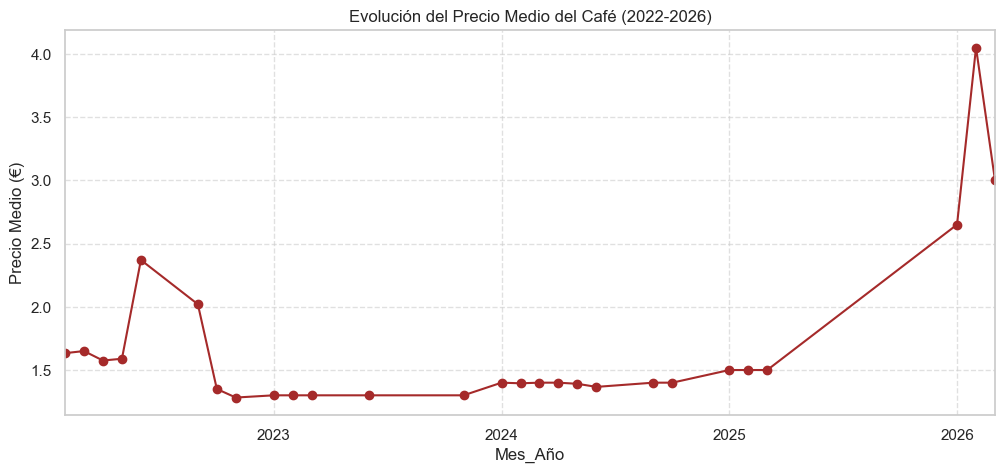


📍 TUS TEMPLOS DEL CAFÉ (Top 3 por gasto):
Descripción
Café                       323.94
Cafés Trastienda + Agua      4.70
Café La Morena pre exam      3.80
Name: Importe, dtype: float64


In [23]:
# 1. Filtrar todas las filas que contengan la palabra "café" (sin importar mayúsculas)
df_cafe = df[df['Descripción'].str.contains('café', case=False, na=False)].copy()

# 2. Calcular estadísticas de "Supervivencia Cafetera"
total_cafe = df_cafe['Importe'].sum()
num_cafes = len(df_cafe)
precio_medio_cafe = df_cafe['Importe'].mean()
max_pago_cafe = df_cafe['Importe'].max()

print("☕ INFORME DE EXTRACCIÓN: EL COSTO DEL CAFÉ")
print("="*40)
print(f"💰 Gasto total acumulado: {total_cafe:,.2f} €")
print(f"🔢 Número total de cafés registrados: {num_cafes}")
print(f"⚖️ Precio medio por café: {precio_medio_cafe:.2f} €")
print(f"🚀 Gasto máximo en una sola sesión de café: {max_pago_cafe:.2f} €")

# 3. Evolución del precio del café (¿Te han subido el precio en tus sitios fijos?)
df_cafe['Mes_Año'] = df_cafe['Fecha'].dt.to_period('M')
evolucion_cafe = df_cafe.groupby('Mes_Año')['Importe'].mean()

plt.figure(figsize=(12, 5))
evolucion_cafe.plot(kind='line', marker='o', color='brown')
plt.title('Evolución del Precio Medio del Café (2022-2026)')
plt.ylabel('Precio Medio (€)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 4. Los "Top 3" sitios donde más café tomas
print("\n📍 TUS TEMPLOS DEL CAFÉ (Top 3 por gasto):")
print(df_cafe.groupby('Descripción')['Importe'].sum().sort_values(ascending=False).head(3))

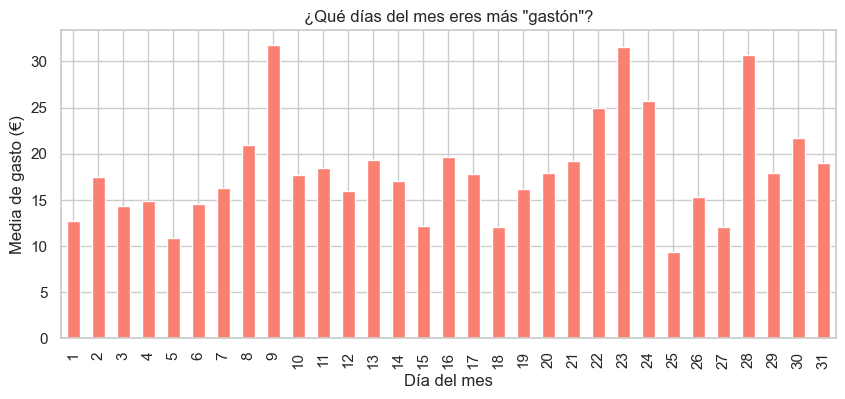

In [10]:
# Velocidad de gasto tras un ingreso grande
df['Dia_Mes'] = df['Fecha'].dt.day
gasto_por_dia_mes = df[df['Tipo'] == 'Gasto'].groupby('Dia_Mes')['Importe'].mean()

plt.figure(figsize=(10,4))
gasto_por_dia_mes.plot(kind='bar', color='salmon')
plt.title('¿Qué días del mes eres más "gastón"?')
plt.xlabel('Día del mes')
plt.ylabel('Media de gasto (€)')
plt.show()

📊 INFORME DE INDEPENDENCIA Y SUPERVIVENCIA 📊
🏠 COSTE FIJO MENSUAL: 221.38 €
   (Esto es lo que necesitas CADA MES solo para cubrir Diésel, Inversiones Fijas y otros compromisos)

💪 TASA DE AUTONOMÍA: 88.3%
   (88.3% de tu dinero lo generas tú; el resto es apoyo familiar)

🔮 PROYECCIÓN MARZO 2027:
   Si mantienes este ritmo, en un año habrás acumulado un ahorro neto de: 2,153.96 €


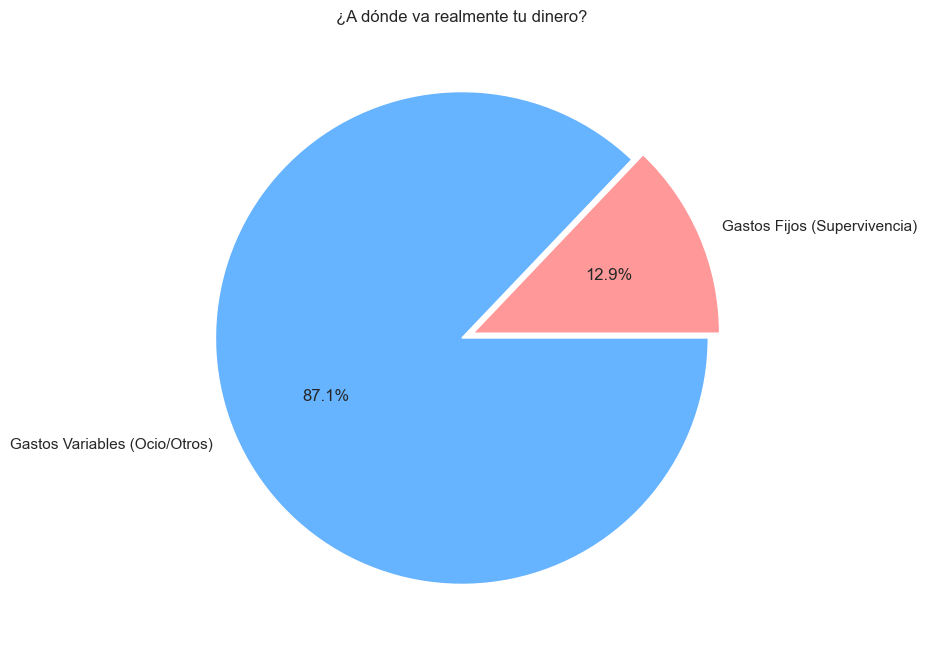

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Cargar el CSV corregido (asegúrate de haber corrido el script anterior)
try:
    df = pd.read_csv('22-26_historico_corregido.csv')
except FileNotFoundError:
    df = pd.read_csv('22-26_historico.csv') # Fallback por si acaso

# Limpieza rápida
df['Fecha'] = pd.to_datetime(df['Fecha'], format='%d/%m/%Y')
def clean_val(x):
    if pd.isna(x): return 0.0
    return float(str(x).replace('"', '').replace('.', '').replace(',', '.'))
df['Importe'] = df['Importe'].apply(clean_val)

# --- CÁLCULOS DE SUPERVIVENCIA ---

# A. Coste Fijo Mensual (Tu "suelo" de gasto)
gastos_fijos_mes = df[df['Compromiso'] == 'Fijo'].groupby(df['Fecha'].dt.to_period('M'))['Importe'].sum().mean()

# B. Tasa de Autonomía
ingresos_papa = df[df['Descripción'] == 'Papá']['Importe'].sum()
ingresos_propios = df[(df['Tipo'] == 'Ingreso') & (df['Descripción'] != 'Papá')]['Importe'].sum()
tasa_autonomia = (ingresos_propios / (ingresos_propios + ingresos_papa)) * 100 if (ingresos_propios + ingresos_papa) > 0 else 0

# C. Proyección de Patrimonio a 12 meses
# Calculamos ahorro medio mensual real (Ingresos totales - Gastos totales)
balance_mensual = df.groupby(df['Fecha'].dt.to_period('M'))['Importe'].apply(
    lambda x: df.loc[x.index, 'Importe'][df.loc[x.index, 'Tipo'] == 'Ingreso'].sum() - 
              df.loc[x.index, 'Importe'][df.loc[x.index, 'Tipo'] == 'Gasto'].sum()
).mean()

patrimonio_estimado_2027 = balance_mensual * 12

print("📊 INFORME DE INDEPENDENCIA Y SUPERVIVENCIA 📊")
print("="*45)
print(f"🏠 COSTE FIJO MENSUAL: {gastos_fijos_mes:.2f} €")
print(f"   (Esto es lo que necesitas CADA MES solo para cubrir Diésel, Inversiones Fijas y otros compromisos)")

print(f"\n💪 TASA DE AUTONOMÍA: {tasa_autonomia:.1f}%")
print(f"   ({tasa_autonomia:.1f}% de tu dinero lo generas tú; el resto es apoyo familiar)")

print(f"\n🔮 PROYECCIÓN MARZO 2027:")
print(f"   Si mantienes este ritmo, en un año habrás acumulado un ahorro neto de: {patrimonio_estimado_2027:,.2f} €")
print("="*45)

# --- GRÁFICO DE ESTRUCTURA DE GASTO ---
labels = ['Gastos Fijos (Supervivencia)', 'Gastos Variables (Ocio/Otros)']
fijos = df[df['Compromiso'] == 'Fijo']['Importe'].sum()
variables = df[df['Compromiso'] == 'Variable']['Importe'].sum()

plt.figure(figsize=(8, 8))
plt.pie([fijos, variables], labels=labels, autopct='%1.1f%%', colors=['#ff9999','#66b3ff'], explode=(0.05, 0))
plt.title('¿A dónde va realmente tu dinero?')
plt.show()


# 2026 - 27

🏠 HOJA DE RUTA: MUDANZA 2027 (Datos de 2026) 🏠
💰 Ahorro Neto Mensual medio en 2026: 742.62 €
📈 Inversión Mensual media en 2026: 152.32 €
🚀 Bolsa de Mudanza (Ahorro + Inversión): 1199.59 €/mes

📉 COMPROBACIÓN DE RESTRICCIÓN:
   Tu ticket medio en Ocio ha bajado un 3.5% respecto a años anteriores.

💡 Diagnóstico para 2027:
   ✅ Tienes un perfil sólido para un alquiler de ~500-600€.


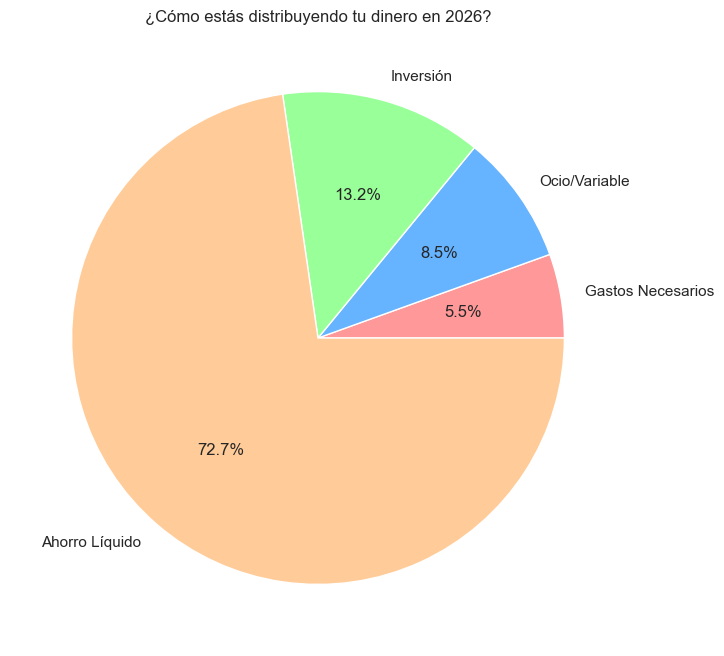

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Filtrar solo datos de 2026
df_2026 = df[df['Fecha'].dt.year == 2026].copy()

# 2. Análisis de Capacidad de Ahorro Real 2026
ingresos_26 = df_2026[df_2026['Tipo'] == 'Ingreso']['Importe'].sum()
gastos_26 = df_2026[df_2026['Tipo'] == 'Gasto']['Importe'].sum()
inversion_26 = df_2026[df_2026['Tipo'] == 'Inversión']['Importe'].sum()

ahorro_mensual_medio = (ingresos_26 - gastos_26 - inversion_26) / df_2026['Fecha'].dt.month.nunique()
capacidad_total_mes = ahorro_mensual_medio + inversion_26 # Lo que podrías destinar a una vivienda

# 3. Análisis de Restricción (¿Estás gastando menos en Ocio?)
# Comparamos Ocio 2026 vs Histórico
ocio_26 = df_2026[df_2026['Categoría'] == 'Ocio']['Importe'].mean()
ocio_hist = df[df['Fecha'].dt.year < 2026][df['Categoría'] == 'Ocio']['Importe'].mean()

print("🏠 HOJA DE RUTA: MUDANZA 2027 (Datos de 2026) 🏠")
print("="*50)
print(f"💰 Ahorro Neto Mensual medio en 2026: {ahorro_mensual_medio:.2f} €")
print(f"📈 Inversión Mensual media en 2026: {inversion_26 / df_2026['Fecha'].dt.month.nunique():.2f} €")
print(f"🚀 Bolsa de Mudanza (Ahorro + Inversión): {capacidad_total_mes:.2f} €/mes")

print(f"\n📉 COMPROBACIÓN DE RESTRICCIÓN:")
reduccion = ((ocio_hist - ocio_26) / ocio_hist) * 100 if ocio_hist > 0 else 0
print(f"   Tu ticket medio en Ocio ha bajado un {reduccion:.1f}% respecto a años anteriores.")

# 4. Simulación de Alquiler
print(f"\n💡 Diagnóstico para 2027:")
if capacidad_total_mes > 600:
    print("   ✅ Tienes un perfil sólido para un alquiler de ~500-600€.")
else:
    print("   ⚠️ Vas ajustado para una mudanza solo; considera reducir más gastos variables.")

# Gráfico de Queso: Destino de cada Euro en 2026
labels = ['Gastos Necesarios', 'Ocio/Variable', 'Inversión', 'Ahorro Líquido']
necesario = df_2026[(df_2026['Tipo'] == 'Gasto') & (df_2026['Compromiso'] == 'Fijo')]['Importe'].sum()
ocio = df_2026[(df_2026['Categoría'] == 'Ocio')]['Importe'].sum()
inv = inversion_26
ahorro = ingresos_26 - necesario - ocio - inv

plt.figure(figsize=(8, 8))
plt.pie([necesario, ocio, inv, ahorro], labels=labels, autopct='%1.1f%%', colors=['#ff9999','#66b3ff','#99ff99','#ffcc99'])
plt.title('¿Cómo estás distribuyendo tu dinero en 2026?')
plt.show()

In [27]:
import pandas as pd

# --- CONFIGURACIÓN DEL USUARIO ---
# Pon aquí la cifra exacta que tenías ahorrada a 1 de enero de 2026
AHORRO_INICIAL_2026 = 4880.0  # <--- CAMBIA ESTA CIFRA por la real
# --------------------------------

# 1. Calcular el Balance Real Acumulado en 2026 (Ingresos - Gastos - Inversiones)
df_2026 = df[df['Fecha'].dt.year == 2026].copy()
balance_total_2026 = (
    df_2026[df_2026['Tipo'] == 'Ingreso']['Importe'].sum() - 
    df_2026[df_2026['Tipo'] == 'Gasto']['Importe'].sum() - 
    df_2026[df_2026['Tipo'] == 'Inversión']['Importe'].sum()
)

# 2. Tu situación actual HOY (Ahorro Inicial + lo generado este año)
capital_actual = AHORRO_INICIAL_2026 + balance_total_2026

# 3. Proyección a final de año (Diciembre 2026)
# Estimamos lo que generarás en los meses que faltan (Abril-Diciembre = 9 meses)
ahorro_mensual_2026 = balance_total_2026 / df_2026['Fecha'].dt.month.nunique()
capital_final_año = capital_actual + (ahorro_mensual_2026 * 9)

# 4. Análisis de "Quema de Efectivo" (Burn Rate) en 2027
# Si el dinero libre es -349.69€, veamos cuánto te durarían los ahorros
deficit_mensual = 349.69 
meses_supervivencia = capital_final_año / deficit_mensual

print("🏢 PLAN ESTRATÉGICO DE MUDANZA (CON AHORRO PREVIO) 🏢")
print("="*55)
print(f"💰 Capital disponible hoy (estimado): {capital_actual:.2f} €")
print(f"🎒 Capital con el que llegarás a 2027: {capital_final_año:.2f} €")

print(f"\n📉 ANÁLISIS DE SOSTENIBILIDAD 2027:")
print(f"   Al tener un déficit mensual de {deficit_mensual} €:")
print(f"   Tus ahorros te permitirían vivir {meses_supervivencia:.1f} meses antes de llegar a cero.")

print(f"\n🎯 OBJETIVO DE RECORTE:")
print(f"   Para no tocar tus ahorros en 2027, deberías reducir tu gasto en Ocio")
print(f"   un {((deficit_mensual / (df_2026[df_2026['Categoría'] == 'Ocio']['Importe'].sum()/3)) * 100):.1f}% adicional.")

🏢 PLAN ESTRATÉGICO DE MUDANZA (CON AHORRO PREVIO) 🏢
💰 Capital disponible hoy (estimado): 7107.86 €
🎒 Capital con el que llegarás a 2027: 13791.44 €

📉 ANÁLISIS DE SOSTENIBILIDAD 2027:
   Al tener un déficit mensual de 349.69 €:
   Tus ahorros te permitirían vivir 39.4 meses antes de llegar a cero.

🎯 OBJETIVO DE RECORTE:
   Para no tocar tus ahorros en 2027, deberías reducir tu gasto en Ocio
   un 355.7% adicional.


In [ ]:
# --- ESCENARIO ACTUALIZADO CON MOTO Y PAREJA ---
CAPITAL_HOY = 7107.86
LIMITE_GASTO_MENSUAL = 350.0   # Tu límite de vida (Ocio, Diésel, etc.)
INVERSION_MENSUAL = 125.0
INGRESO_MEDIO_ESTIMADO = 850.0  # Actual (mientras no tengas el contrato de 1400€)
MESES_RESTANTES = 9

# --- VARIABLES CRÍTICAS ---
CUOTA_FINAL_MOTO = 4000.0
ALQUILER_COMPARTIDO = 450.0    # (900 / 2)
SUMINISTROS_ESTIMADOS = 575.0   # (Luz, agua, internet / 2)
GASTOS_ENTRADA_PISO = 1800.0   # Fianza (2 meses) + Muebles básicos + 1er mes (repartido)

# 1. Proyección de ahorro hasta Diciembre 2026
ahorro_mensual_neto = INGRESO_MEDIO_ESTIMADO - LIMITE_GASTO_MENSUAL - INVERSION_MENSUAL
total_ahorrado_dic = ahorro_mensual_neto * MESES_RESTANTES

# 2. Capital disponible a final de año ANTES de pagar la moto
capital_pre_moto = CAPITAL_HOY + total_ahorrado_dic

# 3. Liquidez real para empezar 2027 (Tras pagar la moto)
capital_enero_2027 = capital_pre_moto - CUOTA_FINAL_MOTO

# 4. Análisis de viabilidad con contrato de 1400€
sueldo_nuevo = 1400.0
fijos_nuevos = ALQUILER_COMPARTIDO + SUMINISTROS_ESTIMADOS + INVERSION_MENSUAL
disponible_post_fijos = sueldo_nuevo - fijos_nuevos - LIMITE_GASTO_MENSUAL

print("🏍️ PROYECTO LIQUIDACIÓN MOTO Y MUDANZA 🏠")
print("="*50)
print(f"💰 Capital acumulado a final de año: {capital_pre_moto:,.2f} €")
print(f"📉 Pago Final Moto (Diciembre): -{CUOTA_FINAL_MOTO:,.2f} €")
print(f"🏦 LIQUIDEZ DISPONIBLE 01/01/2027: {capital_enero_2027:,.2f} €")

print(f"\n🗝️ CAPACIDAD DE ENTRADA AL PISO:")
print(f"   Gastos entrada (Fianza/Muebles): {GASTOS_ENTRADA_PISO:,.2f} €")
print(f"   Colchón de seguridad tras mudarte: {capital_enero_2027 - GASTOS_ENTRADA_PISO:,.2f} €")

print(f"\n📈 ESCENARIO LABORAL (Con sueldo de 1400€):")
print(f"   Balance mensual tras alquiler y gastos: +{disponible_post_fijos:,.2f} €")

🏍️ PROYECTO LIQUIDACIÓN MOTO Y MUDANZA 🏠
💰 Capital acumulado a final de año: 14,082.86 €
📉 Pago Final Moto (Diciembre): -4,000.00 €
🏦 LIQUIDEZ DISPONIBLE 01/01/2027: 10,082.86 €

🗝️ CAPACIDAD DE ENTRADA AL PISO:
   Gastos entrada (Fianza/Muebles): 1,800.00 €
   Colchón de seguridad tras mudarte: 8,282.86 €

📈 ESCENARIO LABORAL (Con sueldo de 1400€):
   Balance mensual tras alquiler y gastos: +-100.00 €
